# Practical 6: Decision Making under Uncertainty

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PART A: DEVELOP A DECISION TREE MODEL

First 10 Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   
5  699-14-3026      C  Naypyitaw        Normal            Male   
6  355-53-5943      A     Yangon        Member          Female   
7  315-22-5665      C  Naypyitaw        Normal          Female   
8  665-32-9167      A     Yangon        Member          Female   
9  692-92-5582      B   Mandalay        Member          Female   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33

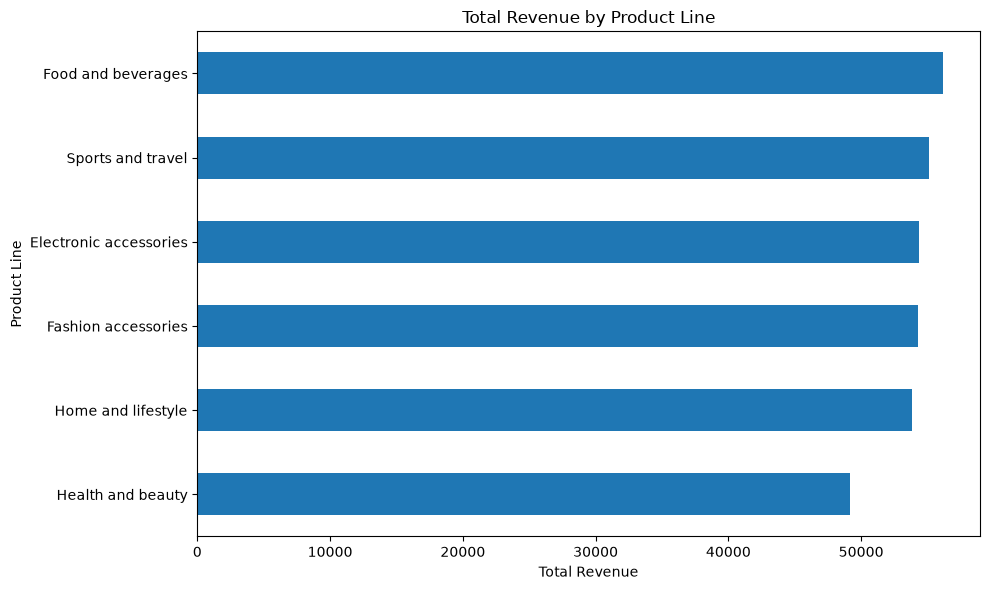

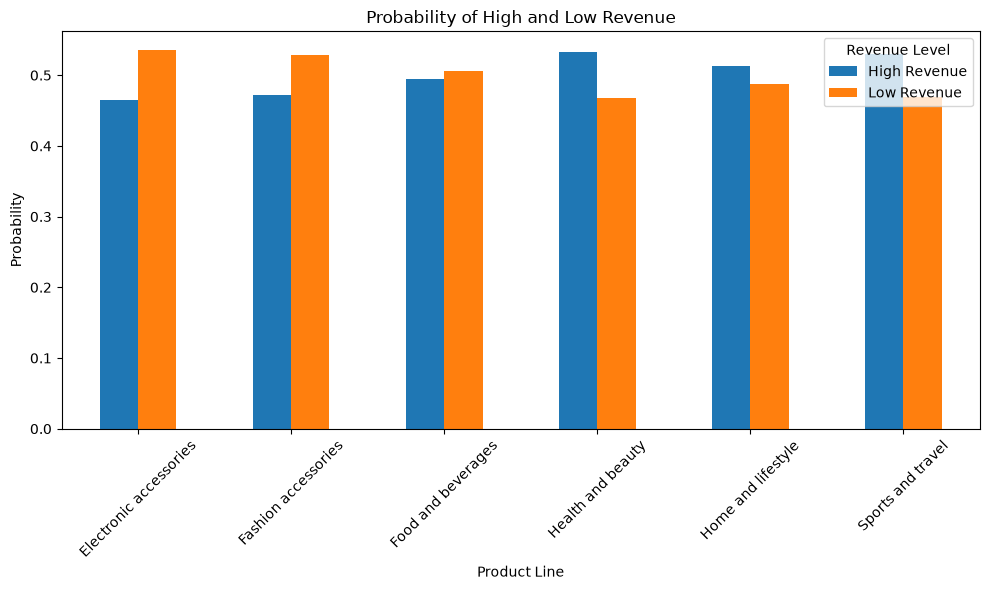


20. Highest Probability of High Revenue: Health and beauty
Probability: 0.5328947368421053
KHUSHI T032


In [3]:
# 1. Load dataset and display first 10 records
df = pd.read_csv("supermarket_sales.csv")

print("First 10 Records:")
print(df.head(10))


# 2. Display number of records, columns, column names and data types
print("\nNumber of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


# 3. Display all unique values of product_line
print("\nUnique Product Lines:")
print(df["product_line"].unique())


# 4. Calculate total revenue generated by each product line
total_revenue = df.groupby("product_line")["revenue"].sum()

print("\nTotal Revenue by Product Line:")
print(total_revenue)


# 5. Calculate average revenue generated by each product line
average_revenue = df.groupby("product_line")["revenue"].mean()

print("\nAverage Revenue by Product Line:")
print(average_revenue)


# 6. Calculate total quantity sold for each product line
total_quantity = df.groupby("product_line")["quantity"].sum()

print("\nTotal Quantity Sold:")
print(total_quantity)


# 7. Calculate median value of revenue
median_revenue = df["revenue"].median()

print("\nMedian Revenue:", median_revenue)


# 8 & 9. Classify transactions as High Revenue or Low Revenue
df["revenue_level"] = np.where(
    df["revenue"] >= median_revenue,
    "High Revenue",
    "Low Revenue"
)

print("\nRevenue Classification:")
print(df[["revenue", "revenue_level"]].head(10))


# 10. Number of High and Low Revenue transactions for each product line
revenue_counts = pd.crosstab(
    df["product_line"],
    df["revenue_level"]
)

print("\nRevenue Counts:")
print(revenue_counts)


# 11. Calculate probability of High and Low Revenue
revenue_probability = revenue_counts.div(
    revenue_counts.sum(axis=1),
    axis=0
)

print("\nRevenue Probabilities:")
print(revenue_probability)


# 12. Verify probabilities add up to 1
probability_check = revenue_probability.sum(axis=1)

print("\nProbability Check:")
print(probability_check)


# 13. Average revenue for High and Low Revenue transactions
revenue_payoff = df.pivot_table(
    index="product_line",
    columns="revenue_level",
    values="revenue",
    aggfunc="mean"
)

print("\nAverage Revenue / Payoff:")
print(revenue_payoff)


# 14. Create DataFrame containing Product Line,
#     Revenue Level, Probability and Payoff

decision_data = []

for product in df["product_line"].unique():

    for level in ["High Revenue", "Low Revenue"]:

        probability = revenue_probability.loc[product, level]
        payoff = revenue_payoff.loc[product, level]

        decision_data.append([
            product,
            level,
            probability,
            payoff
        ])

decision_df = pd.DataFrame(
    decision_data,
    columns=[
        "Product Line",
        "Revenue Level",
        "Probability",
        "Payoff"
    ]
)

print("\nDecision DataFrame:")
print(decision_df)


# 15. Identify decision alternatives and uncertain outcomes
decision_alternatives = df["product_line"].unique()

uncertain_outcomes = ["High Revenue", "Low Revenue"]

print("\nDecision Alternatives:")
print(decision_alternatives)

print("\nUncertain Outcomes:")
print(uncertain_outcomes)


# 16 & 17. Construct and display decision tree
print("\nDECISION TREE")
print("=" * 60)

for product in decision_alternatives:

    print("\n" + product)
    print("   |")

    for level in uncertain_outcomes:

        probability = revenue_probability.loc[product, level]
        payoff = revenue_payoff.loc[product, level]

        print(
            f"   +-- {level} "
            f"(Probability = {probability:.3f}, "
            f"Payoff = {payoff:.2f})"
        )


# 18. Visualization showing total revenue
plt.figure(figsize=(10, 6))

total_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Total Revenue by Product Line")
plt.xlabel("Total Revenue")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()


# 19. Visualization showing probability
#     of High and Low Revenue
revenue_probability.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Probability of High and Low Revenue")
plt.xlabel("Product Line")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend(title="Revenue Level")
plt.tight_layout()
plt.show()


# 20. Product line with highest probability of High Revenue
highest_high_probability_product = (
    revenue_probability["High Revenue"].idxmax()
)

highest_high_probability = (
    revenue_probability["High Revenue"].max()
)

print(
    "\n20. Highest Probability of High Revenue:",
    highest_high_probability_product
)

print(
    "Probability:",
    highest_high_probability
)
print("KHUSHI T032")

#PART B: APPLY EXPECTED VALUE


21. Expected Value helps a business compare different
product lines by considering both the probability of each
possible revenue outcome and its payoff.
The product line with the highest Expected Value is
generally preferred.


22. Expected Value Formula:
EV = Σ (Probability × Payoff)

23. Expected Value of Health and beauty = 323.6430197368422

24. Expected Value of Every Product Line:
product_line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
dtype: float64

25. Expected Value DataFrame:
             Product Line  High Revenue Probability  High Revenue Payoff  \
0       Health and beauty                  0.464706           537.006152   
1  Electronic accessories                  0.471910           512.329375   
2      Home and lifestyle                  0.494253           515.127680   
3       Sports and trave

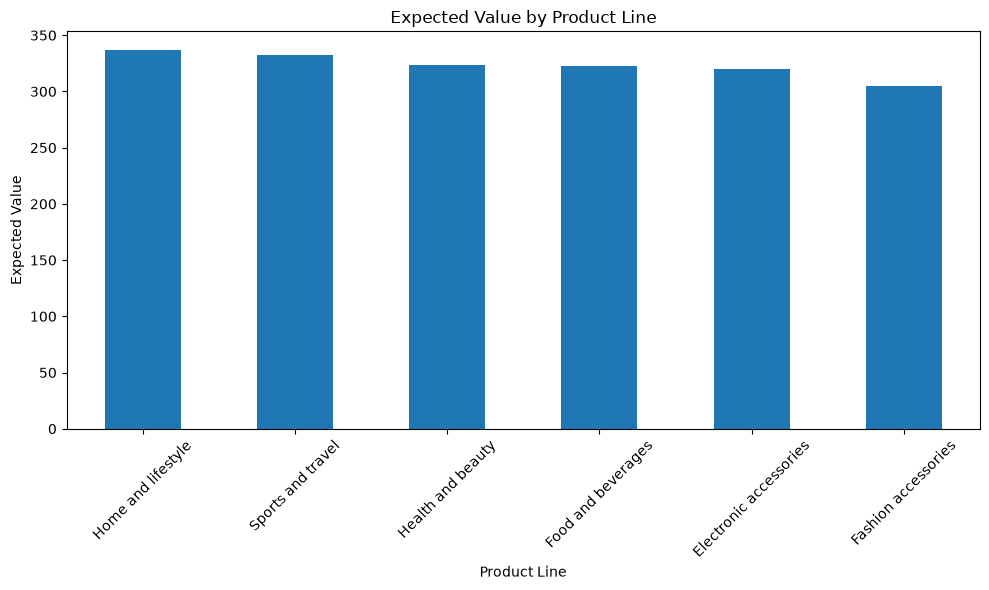


31. Comparison:
Highest High Revenue Probability: Health and beauty
Highest Expected Value: Home and lifestyle

32. Same Product Line? False

33. Probability Change:
Original High Revenue Probability: 0.5125
New High Revenue Probability: 0.6
New Expected Value: 371.2682503752345

34. Payoff Change:
Original High Revenue Payoff: 529.5827378048781
New High Revenue Payoff: 579.5827378048781
New Expected Value: 362.26195625

35. Automatic Expected Values:
product_line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
dtype: float64

Best Product Line:
Home and lifestyle

36. FINAL DECISION TREE

[Health and beauty]
     |
     +--- High Revenue (P=0.533, Payoff=497.22)
     +--- Low Revenue (P=0.467, Payoff=125.62)
     Expected Value = 323.64

[Electronic accessories]
     |
     +--- High Revenue (P=0.465, Payoff=537.

In [ ]:
# 21. Explanation
print("""
21. Expected Value helps a business compare different
product lines by considering both the probability of each
possible revenue outcome and its payoff.
The product line with the highest Expected Value is
generally preferred.
""")


# 22. Mathematical formula
print("\n22. Expected Value Formula:")
print("EV = Σ (Probability × Payoff)")


# 23. Calculate EV for one product line
example_product = decision_alternatives[0]

example_ev = (
    revenue_probability.loc[example_product, "High Revenue"]
    * revenue_payoff.loc[example_product, "High Revenue"]
    +
    revenue_probability.loc[example_product, "Low Revenue"]
    * revenue_payoff.loc[example_product, "Low Revenue"]
)

print("\n23. Expected Value of", example_product, "=", example_ev)


# 24. Calculate EV for every product line
expected_values = (
    revenue_probability * revenue_payoff
).sum(axis=1)

print("\n24. Expected Value of Every Product Line:")
print(expected_values)


# 25. Create final Expected Value DataFrame
ev_df = pd.DataFrame({
    "Product Line": decision_alternatives,

    "High Revenue Probability":
        revenue_probability["High Revenue"].values,

    "High Revenue Payoff":
        revenue_payoff["High Revenue"].values,

    "Low Revenue Probability":
        revenue_probability["Low Revenue"].values,

    "Low Revenue Payoff":
        revenue_payoff["Low Revenue"].values,

    "Expected Value":
        expected_values.values
})

print("\n25. Expected Value DataFrame:")
print(ev_df)


# 26. Compare Expected Values
print("\n26. Expected Value Comparison:")
print(
    ev_df[
        ["Product Line", "Expected Value"]
    ].sort_values(
        "Expected Value",
        ascending=False
    )
)


# 27. Product line with highest Expected Value
highest_ev_product = expected_values.idxmax()
highest_ev = expected_values.max()

print("\n27. Highest Expected Value:")
print(highest_ev_product)
print("Expected Value:", highest_ev)


# 28. Product line with lowest Expected Value
lowest_ev_product = expected_values.idxmin()
lowest_ev = expected_values.min()

print("\n28. Lowest Expected Value:")
print(lowest_ev_product)
print("Expected Value:", lowest_ev)


# 29. Rank all product lines
ranking = expected_values.sort_values(
    ascending=False
)

print("\n29. Ranking from Highest to Lowest Expected Value:")
print(ranking)


# 30. Bar chart comparing Expected Values
plt.figure(figsize=(10, 6))

ranking.plot(kind="bar")

plt.title("Expected Value by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Expected Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 31. Compare highest High Revenue probability
#     with highest Expected Value
print("\n31. Comparison:")

print(
    "Highest High Revenue Probability:",
    highest_high_probability_product
)

print(
    "Highest Expected Value:",
    highest_ev_product
)


# 32. Check whether they are the same
same_product = (
    highest_high_probability_product == highest_ev_product
)

print("\n32. Same Product Line?", same_product)

# 33. Change probability and recalculate EV

test_product = highest_ev_product

original_high_probability = revenue_probability.loc[
    test_product, "High Revenue"
]

original_low_probability = revenue_probability.loc[
    test_product, "Low Revenue"
]

high_payoff = revenue_payoff.loc[
    test_product, "High Revenue"
]

low_payoff = revenue_payoff.loc[
    test_product, "Low Revenue"
]

# Change High Revenue probability to 0.60
new_high_probability = 0.60
new_low_probability = 1 - new_high_probability

new_ev_probability = (
    new_high_probability * high_payoff
    +
    new_low_probability * low_payoff
)

print("\n33. Probability Change:")
print("Original High Revenue Probability:",
      original_high_probability)

print("New High Revenue Probability:",
      new_high_probability)

print("New Expected Value:",
      new_ev_probability)

# 34. Change payoff and recalculate EV

new_high_payoff = high_payoff + 50

new_ev_payoff = (
    original_high_probability * new_high_payoff
    +
    original_low_probability * low_payoff
)

print("\n34. Payoff Change:")
print("Original High Revenue Payoff:",
      high_payoff)

print("New High Revenue Payoff:",
      new_high_payoff)

print("New Expected Value:",
      new_ev_payoff)


# 35. Automatic Expected Value calculation

def calculate_expected_values(data):

    counts = pd.crosstab(
        data["product_line"],
        data["revenue_level"]
    )

    probabilities = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    payoffs = data.pivot_table(
        index="product_line",
        columns="revenue_level",
        values="revenue",
        aggfunc="mean"
    )

    ev = (
        probabilities["High Revenue"]
        * payoffs["High Revenue"]
        +
        probabilities["Low Revenue"]
        * payoffs["Low Revenue"]
    )

    best_product = ev.idxmax()

    return ev, best_product


automatic_ev, best_product = calculate_expected_values(df)

print("\n35. Automatic Expected Values:")
print(automatic_ev)

print("\nBest Product Line:")
print(best_product)

# 36. Display final decision tree with Expected Value
print("\n36. FINAL DECISION TREE")
print("=" * 70)

for product in decision_alternatives:

    print(f"\n[{product}]")
    print("     |")

    high_p = revenue_probability.loc[
        product, "High Revenue"
    ]

    high_pay = revenue_payoff.loc[
        product, "High Revenue"
    ]

    low_p = revenue_probability.loc[
        product, "Low Revenue"
    ]

    low_pay = revenue_payoff.loc[
        product, "Low Revenue"
    ]

    product_ev = expected_values.loc[product]

    print(
        f"     +--- High Revenue "
        f"(P={high_p:.3f}, Payoff={high_pay:.2f})"
    )

    print(
        f"     +--- Low Revenue "
        f"(P={low_p:.3f}, Payoff={low_pay:.2f})"
    )

    print(f"     Expected Value = {product_ev:.2f}")

# 37. Business Recommendation
print("\n37. BUSINESS RECOMMENDATION")

print(
    f"The business should select the '{highest_ev_product}' "
    f"product line because it has the highest Expected Value "
    f"of {highest_ev:.2f}. This indicates that, considering "
    f"both revenue probabilities and payoffs, it provides "
    f"the best expected financial outcome among the product lines."
)
print("KHUSHI T032")